# InferenceOps Submission — Multi-turn Conversational Assistant on vLLM

**One agentic use case, end-to-end: client → nginx → gateway → SSH tunnel → vLLM, then experiments, a model/instance memo, and a full-path dashboard.**

> Pinned run context (fill `<…>` from the run host before grading):
> GPU `gpu_1x_a10` (NVIDIA A10, 24 GB), single GPU, `--tensor-parallel-size 1`, **$1.29/GPU-hr** (Lambda Cloud).
> vLLM `<vLLM version — confirm from run host>`. Models: `Qwen/Qwen3-4B`, `Qwen/Qwen3.5-4B` (original BF16 weights, not quantized).
> Sample data committed at `results/experiments_with_completion_stats.csv` (55 runs). Figures in `figures/submission/`.

## 1. Story — agentic use case & SLOs

### Use case
A **multi-turn conversational assistant** serving many users at once. Each user session is a
sequential dialogue: the agent must carry the full conversation history into every new turn, so
prompts grow turn-over-turn and decode dominates the work. This is the realistic shape of an
assistant/agent backend.

The load driver is **`sharegpt_turn_bench.py`**, which replays **64 real ShareGPT conversations**
concurrently through the production path. Each "session" is one in-flight conversation; within a
session, turns are sent **sequentially**, so the system sees a steady population of `max_sessions`
concurrent multi-turn chats. (The original single-shot CrewAI client, `crew.py`, has been retired in
favor of this multi-turn driver, which exercises the real agentic traffic shape.)

### User journey & failure modes
1. User sends a turn → request flows `client → nginx → gateway → tunnel → vLLM`.
2. vLLM admits the request if KV-cache has room; otherwise it **queues**
   (`vllm_num_requests_waiting`).
3. Tokens stream back; the next turn re-sends the (now longer) history.

Failure modes we actually observe:
- **KV-cache saturation under concurrency** → `vllm_kv_cache_usage_perc_max → 1.0`, queue depth
  climbs, tail latency blows up (§3, insight 3).
- **Long completions inflate p95** — raising `max_tokens` 1024→2048 roughly doubles e2e-p95
  (insight 5).
- **Timeouts** at high concurrency once requests sit in the vLLM queue.

### SLIs / SLOs (caller-visible path)
| SLI | Metric source | Target (illustrative SLO) |
|---|---|---|
| Time to first token (responsiveness) | vLLM `vllm_time_to_first_token_seconds_p50` | p50 ≤ 0.5 s |
| Per-user throughput | gateway `llm_gateway_completion_tokens_per_second_p50` (≈ 1/`vllm_inter_token_latency`) | ≥ 25 tok/s |
| End-to-end latency | vLLM `vllm_e2e_request_latency_seconds` p50/p95 | p95 ≤ 60 s |
| Cost efficiency | gateway `llm_gateway_cost_per_completion_token_usd` | ≤ $10 / 1M completion tok |
| Scalability | concurrent sessions before p95 breaks SLO | ≥ 32 sessions/GPU |

> **Why these (not gateway-side latency):** gateway timing metrics measure gateway *processing*
> time (1–200 ms), **not** model latency (13–30 s). SLOs are anchored on **vLLM** TTFT + inter-token
> latency + e2e (see caveat 2).

### Hypothesis → result
For a decode-bound chat workload with growing shared history, the textbook levers are
**prefix caching** (re-use the shared conversation prefix) and **speculative decoding** (cheaper
decode when memory-bound). Part B **largely refutes both under batched concurrency**: at 16–64
concurrent sessions the GPU is already compute-bound from batching, so spec decoding mostly fails to
pay off and roughly doubles KV pressure; prefix-caching shows no measurable hit on this static
replay (insights 1–3, caveat 1).

## 2. End-to-end path + InferenceOps

```mermaid
flowchart LR
    C["Client<br/>sharegpt_turn_bench.py<br/>(64 convs, max_sessions concurrent)<br/>X-Technique header"]
    N["nginx LB<br/>127.0.0.1:8780<br/>monitoring/nginx-gateway-lb.conf"]
    G["gateway.py (FastAPI)<br/>127.0.0.1:8765<br/>routing • X-Technique • /health<br/>Prometheus llm_gateway_* :9101"]
    T["SSH tunnel<br/>ssh -L 8000:127.0.0.1:8000"]
    V["vLLM serve<br/>instance :8000<br/>Qwen3-4B / Qwen3.5-4B<br/>/metrics (vllm_*)"]
    P["Prometheus :9090<br/>+ Grafana :3000"]

    C --> N --> G --> T --> V
    G -. scrape :9101 .-> P
    V -. scrape :8000/metrics .-> P
```

### Which metric belongs to which hop
| Hop | Port | What to watch |
|---|---|---|
| nginx LB | 8780 | `502`/upstream errors, connection refused (gateway down) |
| gateway | 8765 / metrics 9101 | `llm_gateway_requests_total`, `llm_gateway_*` rate/duration, `/health` |
| SSH tunnel | 8000 | connectivity (refused on `127.0.0.1:8000` ⇒ tunnel or vLLM down) |
| vLLM | 8000 `/metrics` | `vllm_kv_cache_usage_perc`, `vllm_num_requests_waiting`, TTFT/ITL/e2e, spec-decode accept rate |

### InferenceOps — "where we look first"
If latency or errors spike, check the layers **in order**:
1. **nginx** — `502`/upstream (is the gateway up on 8765?).
2. **gateway** — `llm_gateway_*` rate/duration on `:9101`, `/health`.
3. **tunnel** — can the laptop reach `127.0.0.1:8000`?
4. **vLLM** — `/metrics`: `vllm_kv_cache_usage_perc`, `vllm_num_requests_waiting`.

In this workload the **first real signal of trouble is
`vllm_kv_cache_usage_perc_max → 1.0` with `num_requests_waiting` climbing** — a vLLM-layer
admission/KV problem, **not** an LB or gateway fault. The LB/gateway latencies stay flat (sub-second)
while the model's e2e latency grows to tens of seconds.

## 3. Part B — Experiments (engine + gateway in the loop)

### 3.1 Workload, holds, and matrix
The agentic workload is the multi-turn conversational replay from §1, driven through the **full
production path** (nginx → gateway → tunnel → vLLM), never bypassed.

**Held constant across every arm:** original (non-quantized) Qwen weights, `--tensor-parallel-size 1`,
the gateway, the prompt set (64 ShareGPT conversations), and the cost basis. **Varied:** the model,
the vLLM engine config (`mode`), and a load sweep `(max_turns, max_sessions, max_tokens)`.

**Models (2):** `q3_4b` = Qwen3-4B, `q35_4b` = Qwen3.5-4B (original weights, BF16).

**Engine arms — real `vllm serve` deltas** (exact flags in `experiments-execution.md`):

| mode | engine delta (`--speculative-config` JSON unless noted) | model | `--max-model-len` |
|---|---|---|---|
| `base-conv` | none (vLLM defaults) | both | q35 262144 · q3 35000 |
| `prefix-cache` | `--enable-prefix-caching` | both | q35 262144 · q3 35000 |
| `ngram-2` | `{"method":"ngram","num_speculative_tokens":2,"prompt_lookup_min":2,"prompt_lookup_max":2}` | both | q35 80000 · q3 35000 |
| `dflash-2` | `{"method":"dflash","model":"z-lab/Qwen3.5-4B-DFlash","num_speculative_tokens":2}` (q3 uses `z-lab/Qwen3-4B-DFlash-b16`) | both | q35 80000 · q3 35000 |
| `mtp-2` | `{"method":"qwen3_next_mtp","num_speculative_tokens":2}` | q35 only | 262144 |
| `eagle3-2` | `{"method":"eagle3","model":"AngelSlim/Qwen3-4B_eagle3","num_speculative_tokens":2,"draft_tensor_parallel_size":1}` | q3 only | 35000 |
| `draft-q3-06b` | `{"method":"draft_model","model":"Qwen/Qwen3-0.6B","num_speculative_tokens":2}` | q3 only | 35000 |

All arms also add `--language-model-only --reasoning-parser qwen3 --default-chat-template-kwargs '{"enable_thinking": false}'`.
**≥2 distinct engine configs** (baseline vs prefix-cache vs the spec arms) satisfy the rubric;
**the extra labeled dimension** is the load sweep below. Note `--max-model-len` was **not** held
constant across arms (caveat 4).

**Load sweep (5 configs per arm)** — `max_sessions` = concurrency:

| max_turns | max_sessions | max_tokens |
|---|---|---|
| 16 | 16 | 1024 |
| 16 | 32 | 1024 |
| 16 | 64 | 1024 |
| 16 | 64 | 2048 |
| 2 | 32 | 1024 |

→ 2 models × (5–6 arms) × 5 configs = **55 runs** (`results/experiments_with_completion_stats.csv`).

**Pinned reproducibility:** `vllm serve` with the flags above; gateway cost basis
`estimated_gpu_cost = window_s/3600 × GPU_HOURLY_COST_USD` (`gateway.py`); single GPU,
`tensor-parallel-size 1`. **Cost in this submission is reported at the A10 rate `$1.29/GPU-hr`**
(the committed CSV embeds a `$2.50/hr` basis; all `$/1M` figures below are linearly rescaled by
`1.29/2.50 = 0.516` — relative ordering is unchanged).

### 3.2 Gateway / `.env` knobs that matter
- `VLLM_SERVER_PROFILE` — labels metrics with the engine arm in use.
- `VLLM_AUTO_ENGINE_ROUTING=1` + per-port `vllm serve` fleet — route by `X-Technique` without
  restarting gateway between arms.
- `GPU_HOURLY_COST_USD` / `LAMBDA_INSTANCE_TYPE=gpu_1x_a10` — cost proxy.
- `X-Technique` header (set by the bench `--technique`) — drives per-arm labels in `llm_gateway_*`.

### 3.3 Per-arm summary (mean over the 5 load configs)

| model | mode | TTFT p50 (ms) | e2e p50 (s) | e2e p95 (s) | per-user tok/s | system tok/s | KV max† | accept‡ | $/1M tok (A10) |
|---|---|---|---|---|---|---|---|---|---|
| Qwen3.5-4B | base-conv | 305 | 23.1 | 54.9 | 30.3 | 574 | 0.49 | — | 7.0 |
| Qwen3.5-4B | prefix-cache | 273 | 22.2 | 54.7 | 30.9 | 579 | 0.49 | — | 6.9 |
| Qwen3.5-4B | mtp-2 | 383 | **21.3** | **53.6** | **31.5** | **619** | 1.00 | 0.51 | **6.7** |
| Qwen3.5-4B | dflash-2 | 2478 | 25.8 | 64.2 | 26.8 | 588 | 1.00 | 0.44 | 7.9 |
| Qwen3.5-4B | ngram-2 | 284 | 35.8 | 98.4 | 16.7 | 344 | 0.99 | 0.28 | 11.8 |
| Qwen3-4B | base-conv | 183 | 19.5 | 52.2 | 29.2 | 556 | 0.75 | — | 7.1 |
| Qwen3-4B | prefix-cache | 182 | 19.5 | **49.9** | 29.8 | 550 | 0.72 | — | 7.0 |
| Qwen3-4B | eagle3-2 | 282 | **18.4** | 64.0 | 28.1 | **617** | 0.79 | 0.50 | 7.4 |
| Qwen3-4B | dflash-2 | 305 | 20.2 | 69.5 | 27.1 | 566 | 0.99 | 0.53 | 7.9 |
| Qwen3-4B | draft-q3-06b | 1817 | 27.0 | 74.8 | 20.0 | 458 | 1.00 | **0.63** | 10.1 |
| Qwen3-4B | ngram-2 | 156 | 29.4 | 82.0 | 20.0 | 423 | 0.77 | 0.36 | 10.2 |

† KV max at the saturating point `max_sessions=64` (cross-config mean is lower).
‡ accept = `vllm_spec_decode_accepted_over_draft_rate` (accepted ÷ drafted tokens).
*TTFT* = `vllm_time_to_first_token_seconds_p50`; *per-user tok/s* = `llm_gateway_completion_tokens_per_second_p50`;
*system tok/s* = `vllm_generation_tokens_total_rate_per_s`; *$/1M tok* = `cost_per_completion_token_usd × 1e6 × 0.516`.

### 3.4 Concurrency sweep (baseline arm)

| model | sessions | per-user tok/s | system tok/s | e2e p95 (s) | KV max | waiting avg |
|---|---|---|---|---|---|---|
| Qwen3.5-4B | 16 | 34.6 | 477 | 31.4 | 0.16 | 0.00 |
| Qwen3.5-4B | 32 | 34.2 | 598 | 43.0 | 0.29 | 0.00 |
| Qwen3.5-4B | 64 | 24.3 | 598 | 78.7 | 0.49 | 0.19 |
| Qwen3-4B | 16 | 35.0 | 461 | 30.5 | 0.33 | 0.00 |
| Qwen3-4B | 32 | 34.0 | 592 | 45.2 | 0.47 | 0.36 |
| Qwen3-4B | 64 | 21.5 | 567 | 70.1 | 0.75 | 0.81 |

## 4. Evidence — reproduce the tables & plots from committed data

The cell below loads the committed sample data and reproduces the per-arm cost/throughput table at
the A10 rate. (Runs against `results/experiments_with_completion_stats.csv`; no live stack needed.)

In [1]:
import pandas as pd

GPU_HOURLY_USD, CSV_BASIS = 1.29, 2.50           # rescale CSV's $2.50 basis to A10
df = pd.read_csv("results/experiments_with_completion_stats.csv")
df["usd_per_1M"] = df["llm_gateway_cost_per_completion_token_usd"] * 1e6 * (GPU_HOURLY_USD / CSV_BASIS)

summary = (df.groupby(["model", "mode"])
             .agg(ttft_ms=("vllm_time_to_first_token_seconds_p50", lambda s: s.mean()*1e3),
                  e2e_p50=("vllm_e2e_request_latency_seconds_p50", "mean"),
                  e2e_p95=("vllm_e2e_request_latency_seconds_p95", "mean"),
                  user_tps=("llm_gateway_completion_tokens_per_second_p50", "mean"),
                  sys_tps=("vllm_generation_tokens_total_rate_per_s", "mean"),
                  usd_per_1M=("usd_per_1M", "mean"))
             .round(1))
print(summary)

                     ttft_ms  e2e_p50  e2e_p95  user_tps  sys_tps  usd_per_1M
model  mode                                                                  
q35_4b base-conv       304.9     23.1     54.9      30.3    573.8         7.0
       dflash-2       2478.2     25.8     64.2      26.8    588.0         7.9
       mtp-2           383.1     21.3     53.6      31.5    618.7         6.7
       ngram-2         283.7     35.8     98.4      16.7    343.6        11.8
       prefix-cache    273.1     22.2     54.7      30.9    579.2         6.9
q3_4b  base-conv       183.2     19.5     52.2      29.2    555.8         7.1
       dflash-2        305.1     20.2     69.5      27.1    566.3         7.9
       draft-q3-06b   1816.9     27.0     74.8      20.0    457.5        10.1
       eagle3-2        281.7     18.4     64.0      28.1    617.2         7.4
       ngram-2         156.4     29.4     82.0      20.0    423.2        10.2
       prefix-cache    182.0     19.5     49.9      29.8    550.

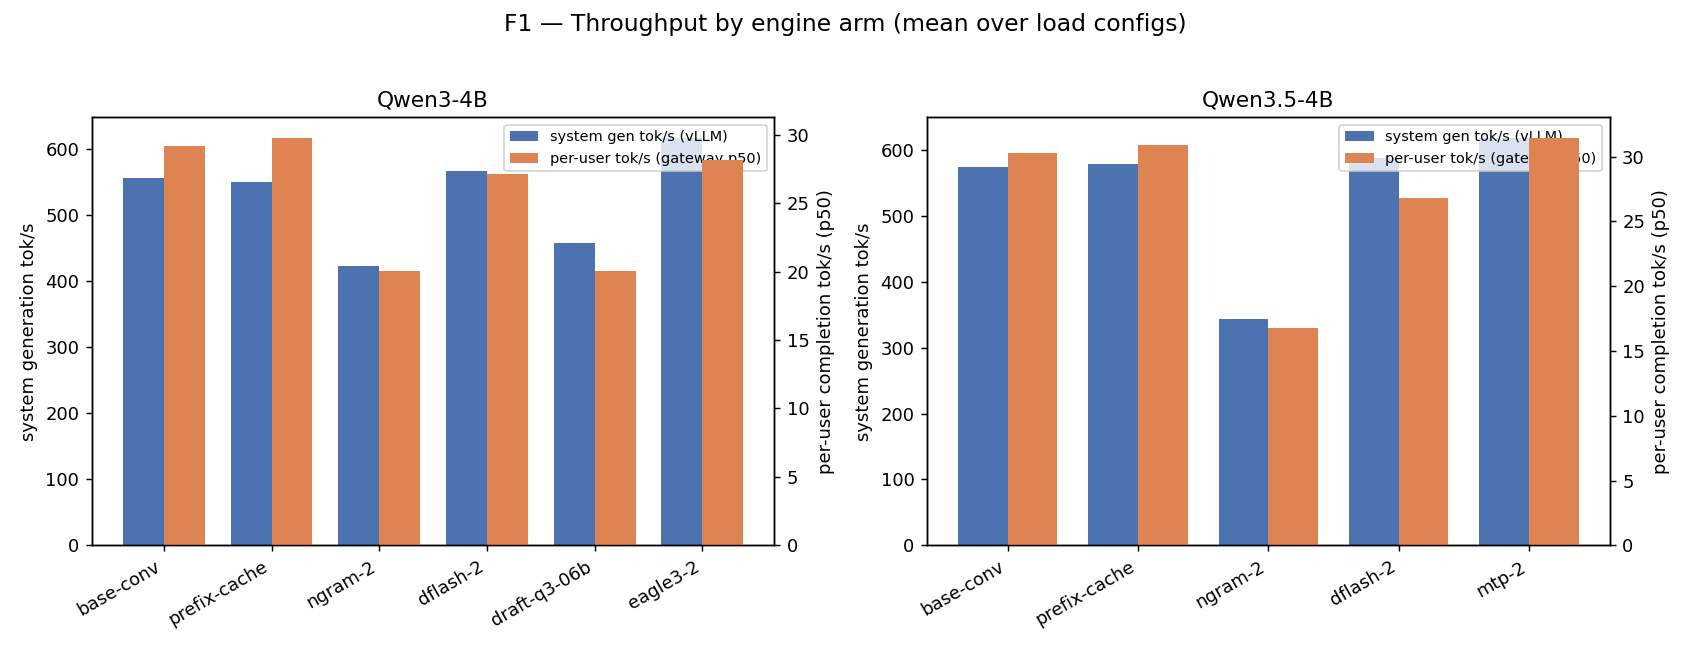

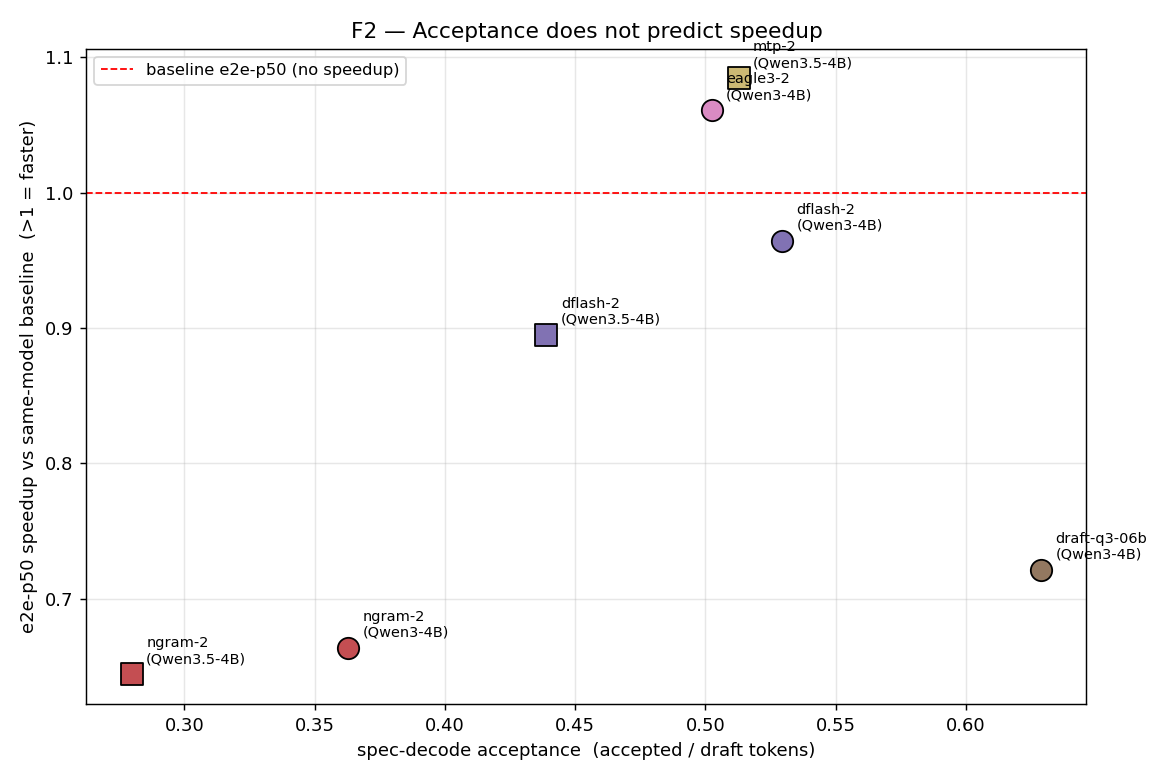

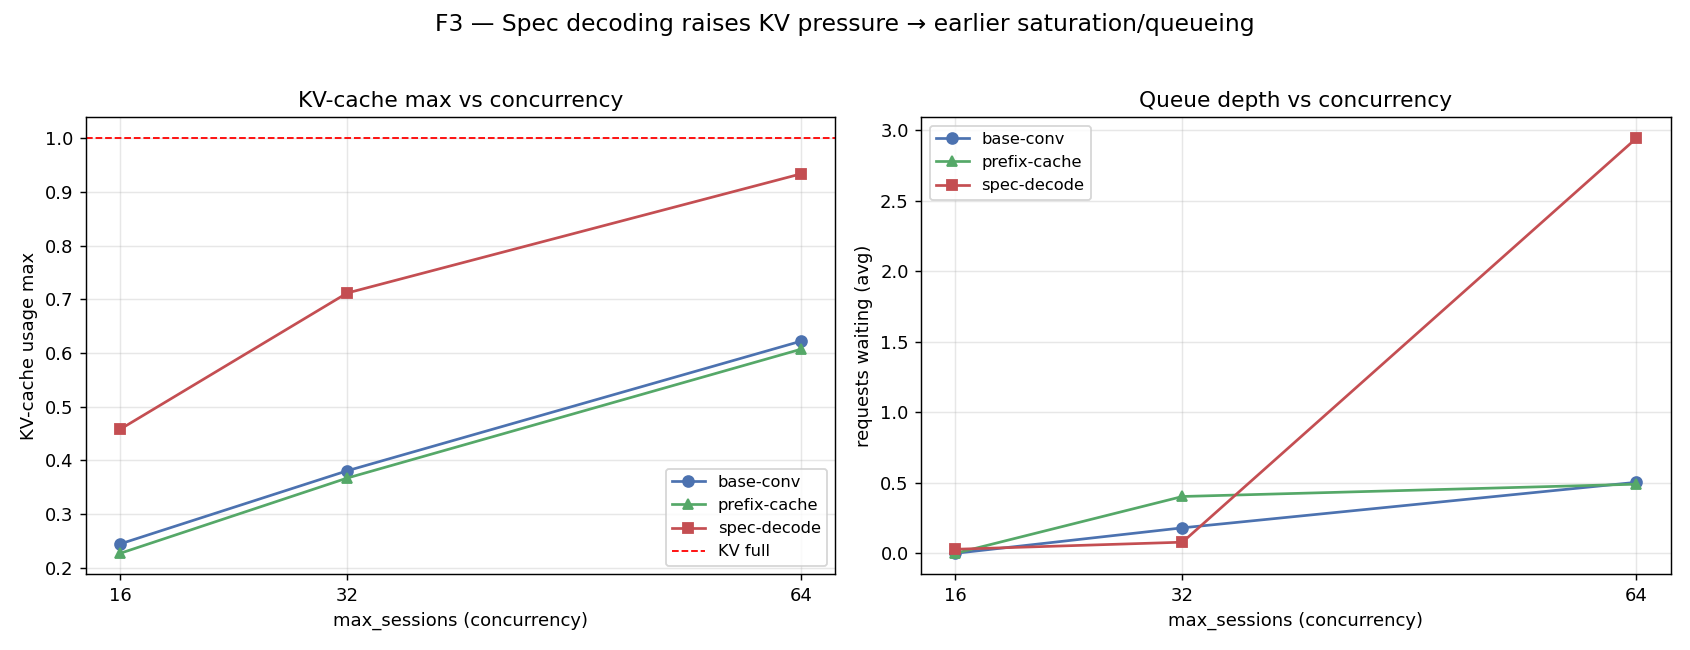

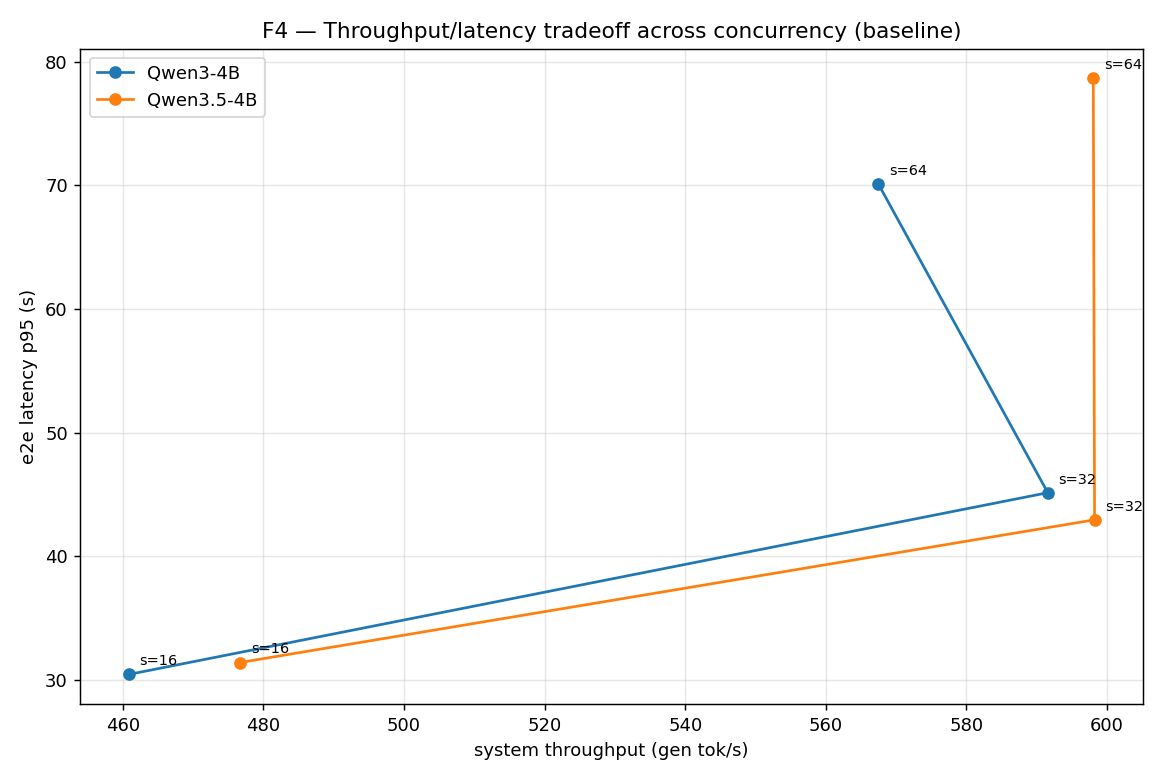

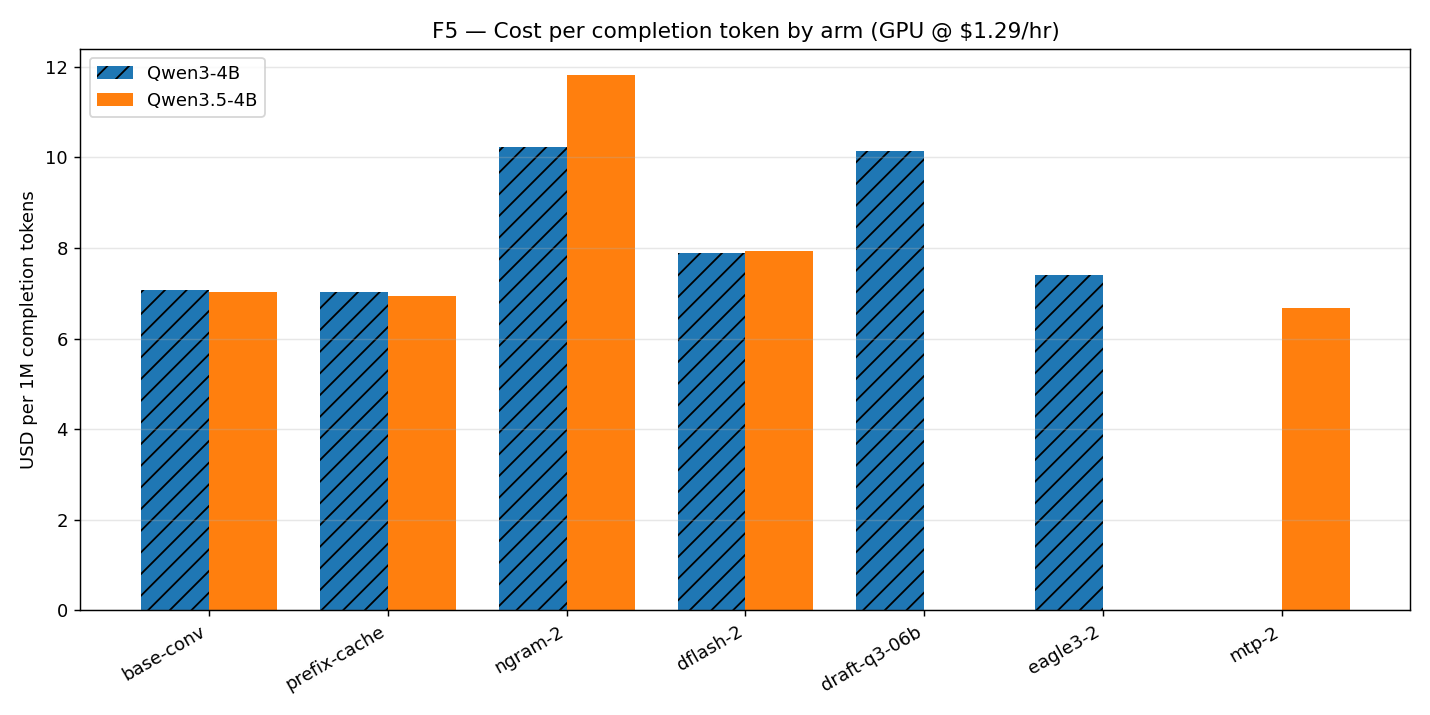

In [2]:
# Reproduce the five Part B figures from the committed CSV (A10 @ $1.29/GPU-hr).
# Reuses scripts/plot_submission_figures.py so the rendered plots match the
# committed PNGs exactly. No live stack needed.
import sys
from pathlib import Path
from IPython.display import Image, display

sys.path.insert(0, "scripts")
import plot_submission_figures as psf

CSV = Path("results/experiments_with_completion_stats.csv")
OUT = Path("figures/submission")
OUT.mkdir(parents=True, exist_ok=True)

dff = psf.load(CSV, gpu_hourly_usd=1.29)
psf.fig_throughput_by_arm(dff, OUT / "f1_throughput_by_arm.png")
psf.fig_acceptance_vs_speedup(dff, OUT / "f2_acceptance_vs_speedup.png")
psf.fig_kv_saturation(dff, OUT / "f3_kv_saturation.png")
psf.fig_throughput_latency_tradeoff(dff, OUT / "f4_throughput_latency_tradeoff.png")
psf.fig_cost_per_token(dff, OUT / "f5_cost_per_token.png")

for name in ["f1_throughput_by_arm", "f2_acceptance_vs_speedup", "f3_kv_saturation",
             "f4_throughput_latency_tradeoff", "f5_cost_per_token"]:
    display(Image(filename=str(OUT / f"{name}.png")))


## 5. Part C — Model & instance memo

### Model
- **Why Qwen3-4B / Qwen3.5-4B:** a 4B target fits a single A10 (24 GB) at BF16 with room for KV,
  has strong multi-turn / instruction-following behavior suited to a conversational agent, and ships
  under a permissive license. Both are close on every headline metric (within ~15%, insight 7).
- **Engine choice is per-model** (data-backed): **Qwen3.5-4B → MTP** is the only spec arm that is
  simultaneously fastest (e2e-p50 21.3 s), highest-throughput (619 tok/s), and cheapest ($6.7/1M).
  **Qwen3-4B → EAGLE3** gives best e2e-p50 (18.4 s) and top system throughput (617 tok/s) at
  near-baseline cost; plain baseline/prefix-cache win the p95 tail.
- **Next model if p95 or cost fails SLO:** move to a **smaller served model** (cuts decode cost and
  KV per request) or a target with a **well-integrated draft head**; avoid external draft models —
  `draft-q3-06b` lost on latency, throughput, and cost here (insights 2, 6).

### Instance / SKU
- **Why A10 24 GB, single GPU, TP=1:** sufficient for a 4B BF16 target plus KV at moderate
  concurrency; cheapest tier that holds the SLOs at ~32 sessions.
- **What breaks if you drop VRAM/tier:** fewer KV blocks → you must cut `--max-model-len`
  (already reduced to 35000 for Qwen3 vs 262144 for Qwen3.5), which lowers max concurrent sessions
  and triggers **earlier KV saturation** (insight 3) and OOM risk for the spec arms (which carry an
  extra draft + ~2× KV footprint). The KV ceiling — not raw FLOPs — is the first wall here.

### Production knob order (cheapest → most expensive)
1. **Gateway / load** — tune `max_sessions` toward ~32 and **cap `max_tokens`** (insights 4–5).
2. **Engine arm** — switch to the per-model winner (MTP / EAGLE3) before touching hardware.
3. **Scale out** — add a second `vllm serve` backend behind nginx/gateway. Re-tuning the engine arm
   is cheaper than adding GPUs, so it comes first.

## 6. Part D — Dashboard (full path, not GPU-only)

A Grafana + Prometheus stack ships with the repo (`monitoring/docker-compose.yml`). Dashboards are
provisioned from JSON under **`monitoring/grafana_dashboards/`**:

| Dashboard JSON | Covers |
|---|---|
| `overview.json` | request volume, error rate, latency over time across the path |
| `gateway-proxy.json` | **gateway** hop — `llm_gateway_*` on `:9101` (rate, duration, TTFT/TPOT, cost) |
| `technique-cost.json` | efficiency — tokens/s and cost proxy broken down by `technique` / `server_profile` |
| `tinyllama-ops.json` | **vLLM** engine panels — `/metrics` via the tunnel (KV usage, waiting, gen tok/s) |

**Layer coverage (call-out):** gateway panels read `llm_gateway_*` from `:9101`; vLLM panels read
`vllm_*` from the instance `:8000/metrics` through the SSH tunnel. The text/legend panels label which
hop each panel belongs to, so the board tells the **full-path** story, not just GPU charts.

**Prometheus scrape targets** (`monitoring/prometheus.yml`, 15 s interval):
- `gateway` → `host.docker.internal:9101` (gateway metrics)
- `vllm_tunnel` → `host.docker.internal:8000` (vLLM `/metrics` via tunnel)

Confirm both **UP** at `http://127.0.0.1:9090/targets`.

> **Note for graders:** per submission choice, the dashboard is shipped as committed Grafana JSON +
> Prometheus config rather than a static screenshot. The spec permits this with a **live-demo**
> option — bring up the stack via §7 and open `http://127.0.0.1:3000` (folder *TinyLlama*) to walk
> the panels live.

## 7. Reproducibility + Reflection

### Run the stack (condensed — full 20-step guide in `README.md`)
```bash
# 0. clone, then configure (no secrets committed)
cp .env.example .env           # set VLLM_BASE_URL, VLLM_SERVER_PROFILE, GPU_HOURLY_COST_USD, LAMBDA_INSTANCE_TYPE
pip install -r requirements.txt

# 1. on the GPU instance: start vLLM (exact flags per arm in experiments-execution.md)
vllm serve Qwen/Qwen3.5-4B --served-model-name qwen3.5-4b --host 0.0.0.0 --port 8000 \
  --tensor-parallel-size 1 --max-model-len 262144 --language-model-only \
  --reasoning-parser qwen3 --default-chat-template-kwargs '{"enable_thinking": false}'

# 2. laptop: tunnel, gateway, nginx
ssh -i ~/.ssh/<key> -L 8000:127.0.0.1:8000 -N ubuntu@<INSTANCE_IP>
python gateway.py                                             # :8765, metrics :9101
cd monitoring && nginx -p /tmp -c "$(pwd)/nginx-gateway-lb.conf"   # :8780

# 3. drive the agent workload through the full path
python sharegpt_turn_bench.py --technique base-conv --mode static \
  --num-conversations 64 --max-conversations 64 \
  --max-turns-per-conv 16 --max-sessions 32 --max-tokens 1024

# 4. monitoring (optional)
cd monitoring && docker compose up -d        # Prometheus :9090, Grafana :3000

# 5. regenerate the figures in this submission (A10 cost basis)
python scripts/plot_submission_figures.py \
  --input-csv results/experiments_with_completion_stats.csv \
  --output-dir figures/submission --gpu-hourly 1.29
```

### Reflection (≤300 words)
The biggest surprise was how **little speculative decoding helped** once the workload was actually
batched. Going in, the mental model was the standard one: chat decode is memory-bound, so drafting
several tokens per verification step should be close to free throughput. Under 16–64 concurrent
sessions that assumption broke — the GPU is already compute-bound from batching, so the extra draft
and verification compute is *not* free. Only the cheapest, tightly-integrated drafts (MTP on Qwen3.5,
EAGLE3 on Qwen3) cleared break-even; `ngram` and an external 0.6B draft were strictly worse on
latency, throughput, **and** cost. Even more counter-intuitive: the **highest-acceptance** arm
(`draft-q3-06b`, 0.63) was among the **slowest**, because acceptance ignores draft cost and KV
footprint. And every spec arm roughly **doubled KV pressure**, saturating the cache at 64 sessions
while baseline stayed at half-full — turning a "speedup" knob into a capacity regression.

**One next instrumentation:** fix the prefix-cache visibility gap. Prefix-cache queries/hits read
zero in every run (caveat 1), so we can't tell whether the static replay simply shares no
cross-session prefix or whether the APC metric isn't being scraped. I'd add explicit
`vllm_prefix_cache_*` panels plus a synthetic shared-system-prompt arm, and split a **true
gateway-side TTFT** (first-byte vs total) so the gateway hop reports real first-token latency instead
of just processing time (caveat 2). Per-request OTLP traces mapped to the §2 diagram would close the
loop on *which hop* owns each millisecond.

## Caveats / data-quality footnotes
1. **Prefix caching shows zero queries/hits in every run** (`vllm_prefix_cache_queries = hits = 0`,
   incl. the `prefix-cache` arm); prefill p50 matches baseline. Either the static ShareGPT replay
   shares no cross-session prefix or the APC metric wasn't scraped — treat prefix-cache as
   **neutral** here, not validated.
2. **Gateway-side latency ≠ model latency.** `llm_gateway_request_duration_seconds` reads 0.05–0.22 s
   and `llm_gateway_time_to_first_token` ~1.6 ms — gateway *processing* time, while true per-request
   time is 13–30 s. Confirmed by `tokens_mean ÷ completion_tps_p50 ≈ vllm_e2e_request_latency_p50`
   and by vLLM TTFT (~0.3 s) / ITL (~36 ms ⇒ ~28 tok/s). **SLOs use vLLM TTFT +
   `vllm_inter_token_latency` + `vllm_e2e_request_latency`.**
3. Early outlier runs came from a dirty environment; numbers here are from the clean re-run export.
4. **`--max-model-len` was not held constant** across arms (q35 base/MTP 262144; q35 dflash/ngram
   80000; all q3 arms 35000). Smaller windows mean fewer KV blocks, so compare KV % *within* a
   model/len group. The headline KV claim (insight 3) rests on the Qwen3.5 MTP-vs-baseline pair
   (both 262144), so it is unaffected. Cross-model latency/throughput comparisons are robust because
   the bottleneck here is compute/batching, not context length.